In [51]:
import os
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl

/tmp/ipykernel_582071/1756506021.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, bbox_to_anchor=(1, -.1), loc='upper right', )


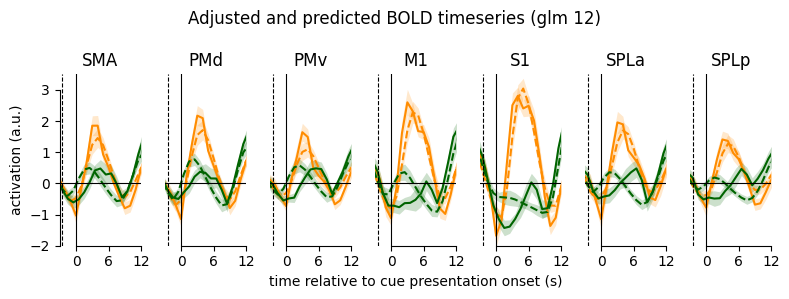

In [52]:
experiment = 'smp2'
H = 'L'
rois = gl.rois['ROI']

hrf12 = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm12', 'hrf.tsv'), sep='\t')
hrf15 = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm15', 'hrf.tsv'), sep='\t')
hrf12_melt = hrf12.melt(id_vars=['roi', 'Hem', 'time', 'kind', 'GoNogo'], value_vars=[str(sn) for sn in gl.sns], var_name='sn', value_name='BOLD')
hrf15_melt = hrf15.melt(id_vars=['roi', 'Hem', 'time', 'kind', 'GoNogo'], value_vars=[str(sn) for sn in gl.sns], var_name='sn', value_name='BOLD')

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 3))

for r, roi in enumerate(rois):
    ax = axs[r]
    data = hrf12_melt[(hrf12_melt.Hem==H) & (hrf12_melt.roi==roi)]
    sb.lineplot(data=data[(data.GoNogo=='go') & (data.kind=='adj')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkorange', err_kws={'linewidth': 0})
    sb.lineplot(data=data[(data.GoNogo=='go') & (data.kind=='hat')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkorange', ls='--', err_kws={'linewidth': 0})
    sb.lineplot(data=data[(data.GoNogo=='nogo') & (data.kind=='adj')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkgreen', err_kws={'linewidth': 0})
    sb.lineplot(data=data[(data.GoNogo=='nogo') & (data.kind=='hat')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkgreen', ls='--', err_kws={'linewidth': 0})
    
    ax.axvline(0, color='k', ls='-', lw=.8)
    ax.axvline(-2.5, color='k', ls='--', lw=.8)
    ax.axhline(0, color='k', ls='-', lw=.8)

    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.spines['bottom'].set_bounds(0, 12)
    ax.set_xticks([0, 6, 12])
    if r == 0:
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_bounds(-2, 3)
    else:
        ax.tick_params('y', width=0)

    ax.set_xlim((-3, 12))
    ax.set_xlabel(None)
    ax.set_ylim((-2, 3.5))

    ax.set_title(rois[r])

ax.legend(frameon=False, bbox_to_anchor=(1, -.1), loc='upper right', )

axs[0].set_ylabel('activation (a.u.)')
axs[3].set_xlabel('time relative to cue presentation onset (s)')
fig.suptitle('Adjusted and predicted BOLD timeseries (glm 12)')
fig.tight_layout()

plt.show()

/tmp/ipykernel_582071/1510500942.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False) #, bbox_to_anchor=(1, -.1), loc='upper right', )


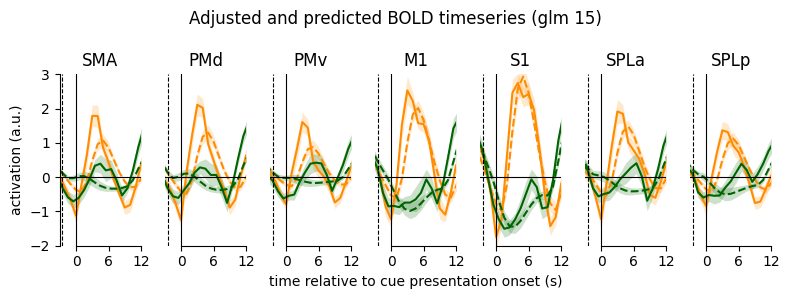

In [54]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 3))

for r, roi in enumerate(rois):
    ax = axs[r]
    data = hrf15_melt[(hrf15_melt.Hem==H) & (hrf15_melt.roi==roi)]
    sb.lineplot(data=data[(data.GoNogo=='go') & (data.kind=='adj')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkorange', err_kws={'linewidth': 0})
    sb.lineplot(data=data[(data.GoNogo=='go') & (data.kind=='hat')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkorange', ls='--', err_kws={'linewidth': 0})
    sb.lineplot(data=data[(data.GoNogo=='nogo') & (data.kind=='adj')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkgreen', err_kws={'linewidth': 0})
    sb.lineplot(data=data[(data.GoNogo=='nogo') & (data.kind=='hat')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkgreen', ls='--', err_kws={'linewidth': 0})
    
    ax.axvline(0, color='k', ls='-', lw=.8)
    ax.axvline(-2.5, color='k', ls='--', lw=.8)
    ax.axhline(0, color='k', ls='-', lw=.8)

    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.spines['bottom'].set_bounds(0, 12)
    ax.set_xticks([0, 6, 12])
    if r == 0:
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_bounds(-2, 3)
    else:
        ax.tick_params('y', width=0)

    ax.set_xlim((-3, 12))
    ax.set_xlabel(None)
    ax.set_ylim((-2, 3))

    ax.set_title(rois[r])

ax.legend(frameon=False) #, bbox_to_anchor=(1, -.1), loc='upper right', )

axs[0].set_ylabel('activation (a.u.)')
axs[3].set_xlabel('time relative to cue presentation onset (s)')
fig.suptitle('Adjusted and predicted BOLD timeseries (glm 15)')
fig.tight_layout()

plt.show()